In [1]:
#  Importing the relevant libraries
import numpy as np
import matplotlib.pyplot as plt
import fgbuster as fg
from fgbuster.component_model import CMB, Dust, Synchrotron
from megatop import BBmeta
import healpy as hp
import os
import time
from pysm3 import Sky, bandpass_unit_conversion
import scipy
from scipy import stats
from tqdm import tqdm
import copy
from fgbuster.observation_helpers import _jysr2rj, _jysr2cmb, _rj2cmb, standardize_instrument
from fgbuster.separation_recipes import MixingMatrix
from astropy.table import Table
# from astropy import units as u
from pysm3 import units as u

In [2]:
frequencies = np.array([27, 39, 93, 145, 225, 280])

In [4]:
instrument = {'frequency': frequencies}
instrument = standardize_instrument(instrument)

use_bandpass = True

if use_bandpass:
    instrument_bandpass = {'frequency': frequencies}
    instrument_bandpass = standardize_instrument(instrument_bandpass)


if use_bandpass:
    bandpasses = np.array([12, 15, 14, 16, 18, 20])*1.0
    N_SAMPLE_BAND = 50
    new_list_of_freqs = []
    freq_and_flat_weights = []
    # weights_jysr_list = []
    # weights_healpy = []
    for f in np.arange(instrument_bandpass.frequency.shape[0]):
        fmin = instrument_bandpass.frequency[f]-bandpasses[f]/2
        fmax = instrument_bandpass.frequency[f]+bandpasses[f]/2
        freqs = np.linspace(fmin, fmax, N_SAMPLE_BAND)
        weights_flat = np.ones(N_SAMPLE_BAND) # for maps in in Jy/sr, additional conversion factor is needed for K_CMB SED in fgbuster
        freq_and_flat_weights.append((freqs, weights_flat))
        # weights_flat_copy = np.ones(N_SAMPLE_BAND) # in Jy/sr

        # weights_Krj = weights_flat * _jysr2rj(freqs)
        # weights_jysr_list.append(weights_jysr)
        # weights_for_conversion = 1.0 /_rj2cmb(freqs)
        weights = weights_flat / _jysr2rj(freqs)
        weights /= _rj2cmb(freqs) # so now on top of the weight we have the conversion factor from K_CMB to Jy/sr
        # weights /= _rj2cmb(freqs)
        weights /= np.trapz(weights, freqs * 1e9) # normalizing the weights and with the inclusion of the conversion factor 
        # it gives the bandpass integrated version of the conversion factor 
        # so that we get the correct units for the integrated quantity (used for fgbuster SED)
        new_list_of_freqs.append((freqs, weights))

        # conv = 1.0 / _jysr2rj(freqs) /_rj2cmb(freqs)
        # weights_units_healpy = np.array([(w * u.Jy / u.sr ).to(u.K_CMB, equivalencies=u.cmb_equivalencies(freq * u.GHz)).value for w, freq in zip(weights_flat_copy, freqs)])
        # weights_units_healpy_normed = weights_units_healpy / np.trapz(weights_units_healpy, freqs * 1e9)
        # weights_healpy.append(weights_units_healpy_normed)


    instrument_bandpass.frequency = np.asarray(new_list_of_freqs)
    freq_and_flat_weights = np.asarray(freq_and_flat_weights)
    # weights_healpy = np.asarray(weights_healpy)

    # freq_and_weights_Krj = copy.deepcopy(instrument_bandpass.frequency)
    # freq_and_weights_Krj[:,1] = freq_and_weights_Krj[:,1] * _jysr2rj(freq_and_weights_Krj[:,0])
# 
    # freq_and_weights_JyOversr = copy.deepcopy(instrument_bandpass.frequency)
    # freq_and_weights_JyOversr[:,1] = freq_and_weights_JyOversr[:,1] * _rj2cmb(freq_and_weights_JyOversr[:,0])
    # freq_and_weights_JyOversr[:,1] /= np.trapz(freq_and_weights_JyOversr[:,1], freq_and_weights_JyOversr[:,0] * 1e9)
    
   

    # print(instrument_bandpass.frequency[0,1,:5])
    # print(weights_healpy[0,:5])




In [5]:
# Initializing the sky model, we ask for maps in K_CMB
sky = Sky(nside=128, preset_strings=['c1',"d0", "s0"], output_unit=u.K_CMB)

In [6]:
# Creating standard maps without bandpass
freq_map = []
for i, freq in tqdm(enumerate(instrument.frequency)):
    freq_map.append(sky.get_emission(freq * u.GHz) ) # * _rj2cmb(freq) )
freq_map = np.array(freq_map)
    

if use_bandpass:
    freq_map_bandpass = []
    # for i, freq in tqdm(enumerate(instrument_bandpass.frequency)): 
    for i, freq in tqdm(enumerate(freq_and_flat_weights)): 
        freq_map_bandpass.append(
            sky.get_emission(freq[0] * u.GHz, 
                            #  freq_and_weights_JyOversr[i,1] * u.Jy/u.sr)  * 
                            freq[1] )
                            # * 
                            # bandpass_unit_conversion(freq_and_weights_JyOversr[i,0] * u.GHz, 
                            #                         #  freq_and_weights_JyOversr[i,1] * u.Jy/u.sr,
                            #                          np.ones(len(freq_and_weights_JyOversr[i,0])) * u.Jy/u.sr,
                            #                          output_unit=u.uK_CMB)
            # sky.get_emission(freq[0] * u.GHz, 
            #                  freq[1] * u.Jy/u.sr, )  
                            


                            )
    freq_map_bandpass = np.array(freq_map_bandpass)

6it [00:04,  1.43it/s]
6it [01:00, 10.13s/it]


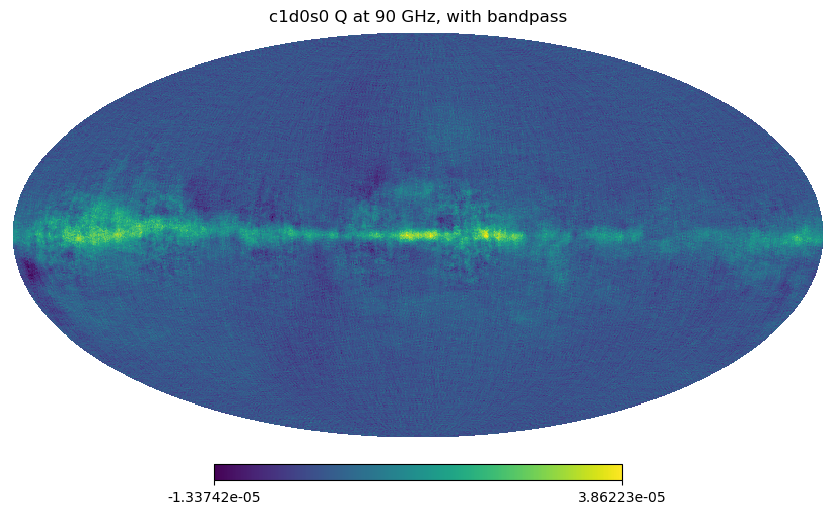

In [7]:
hp.mollview(freq_map_bandpass[2,1], title='c1d0s0 Q at 90 GHz, with bandpass')
plt.show()


In [8]:
# creating the noise map for each frequency channel
noise_maps = []
nside = hp.get_nside(freq_map_bandpass[0])
print('nside =', nside)
noise_lvl_uk = np.array([17.76741806032688, 21.207586012564423, 2.77243249663342, 2.798531403709892, 
                         8.474221515572802, 21.861113346794266]) / hp.nside2resol(nside, arcmin=True)

noise_lvl_k = noise_lvl_uk * 1e-6

for i in range(len(noise_lvl_uk)):
    noise = np.random.normal(0, noise_lvl_k[i], (3,hp.nside2npix(nside)))
    noise_maps.append(noise)
noise_maps = np.array(noise_maps)

noise_cov = (np.ones_like(noise_maps).T * noise_lvl_k**2).T # creating a uniform noise covariance map
noise_cov[:,0] = 0

noisy_freq_map_bandpass = freq_map_bandpass + noise_maps
noisy_freq_map = freq_map + noise_maps




nside = 128


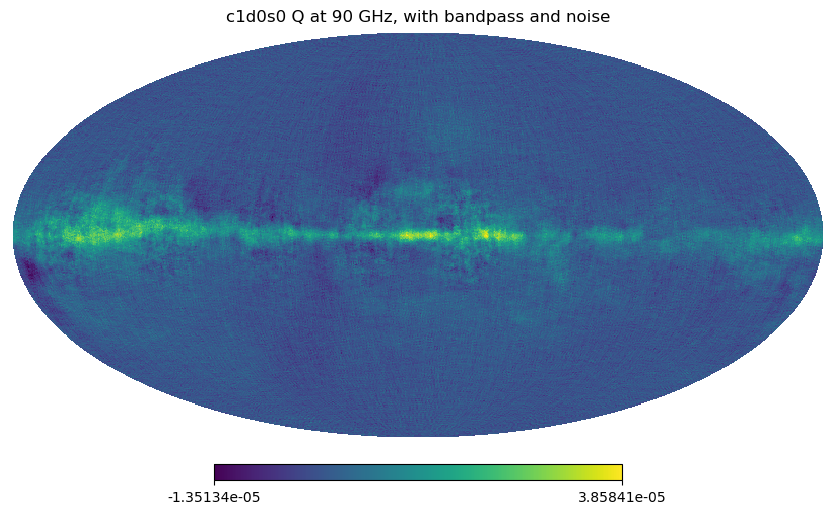

In [9]:
hp.mollview(noisy_freq_map_bandpass[2,1], title='c1d0s0 Q at 90 GHz, with bandpass and noise')
plt.show()


In [10]:
components = [CMB(), Dust(150., temp=20.0), Synchrotron(150.)] # we leave T_dust fixed at 20 K

# Minimization options, copied from BBPipe
options={'disp':False, 'gtol': 1e-12, 'eps': 1e-12, 'maxiter': 100, 'ftol': 1e-12 } 
tol=1e-18
method='TNC'


In [20]:
time_comp_sep = time.time()

res_compsep = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=noisy_freq_map[:,1:], cov=noise_cov[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)
print('success: ',res_compsep.success)
print('x: ', res_compsep.x)



time comp sep = 77.15939736366272
success:  False
x:  [ 1.54001769 -3.00039885]


In [21]:

time_comp_sep = time.time()

res_compsep_bandpass = fg.separation_recipes.weighted_comp_sep(components, instrument_bandpass,
            data=noisy_freq_map_bandpass[:,1:], cov=noise_cov[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)
print('success: ',res_compsep_bandpass.success)
print('x: ', res_compsep_bandpass.x)


time comp sep = 80.14431023597717
success:  True
x:  [ 1.54001767 -3.00038997]


In [22]:

#  testing with basic_comp_sep
time_comp_sep = time.time()

res_compsep_ignore_bandpass = fg.separation_recipes.weighted_comp_sep(components, instrument,
            data=noisy_freq_map_bandpass[:,1:], cov=noise_cov[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)
print('success: ',res_compsep_ignore_bandpass.success)
print('x: ', res_compsep_ignore_bandpass.x)


time comp sep = 21.657433032989502
success:  True
x:  [ 1.53672346 -2.99752413]


In [23]:
sigma_from_fisher = scipy.linalg.sqrtm(res_compsep.Sigma)
print('============= NO BANDPASS =============')
print('============= DUST INDEX ==============')
print('Relative difference in dust index using ouptut Sigma = ', 
      np.abs(sky.components[1].mbb_index - res_compsep.x[0])/ sigma_from_fisher[0,0] )

print('========== SYNCHROTRON INDEX ===========')
print('Relative difference in synchrotron index using ouptut Sigma = ', 
      np.abs(sky.components[2].pl_index - res_compsep.x[1])/ sigma_from_fisher[1,1] )
print('\n\n')

print('=========== WITH BANDPASS =============')
print('============= DUST INDEX ==============')
sigma_from_fisher_bandpass = scipy.linalg.sqrtm(res_compsep_bandpass.Sigma)
print('Relative difference in dust index using ouptut Sigma = ', 
      np.abs(sky.components[1].mbb_index - res_compsep_bandpass.x[0])/ sigma_from_fisher_bandpass[0,0] )
print('========== SYNCHROTRON INDEX ===========')
print('Relative difference in synchrotron index using ouptut Sigma = ', 
      np.abs(sky.components[2].pl_index - res_compsep_bandpass.x[1])/ sigma_from_fisher_bandpass[1,1] )

print('\n\n')

print('=========== IGNORING BANDPASS =============')
print('============= DUST INDEX ==============')
sigma_from_fisher_ignorebandpass = scipy.linalg.sqrtm(res_compsep_ignore_bandpass.Sigma)
print('Relative difference in dust index using ouptut Sigma = ', 
      np.abs(sky.components[1].mbb_index - res_compsep_ignore_bandpass.x[0])/ sigma_from_fisher_ignorebandpass[0,0] )
print('========== SYNCHROTRON INDEX ===========')
print('Relative difference in synchrotron index using ouptut Sigma = ', 
      np.abs(sky.components[2].pl_index - res_compsep_ignore_bandpass.x[1])/ sigma_from_fisher_ignorebandpass[1,1] )

============= NO BANDPASS =============
============= DUST INDEX ==============
Relative difference in dust index using ouptut Sigma =  0.12729570466638612
========== SYNCHROTRON INDEX ===========
Relative difference in synchrotron index using ouptut Sigma =  0.8086322003452066



=========== WITH BANDPASS =============
============= DUST INDEX ==============
Relative difference in dust index using ouptut Sigma =  0.1270490174269454
========== SYNCHROTRON INDEX ===========
Relative difference in synchrotron index using ouptut Sigma =  0.8080099083288932



=========== IGNORING BANDPASS =============
============= DUST INDEX ==============
Relative difference in dust index using ouptut Sigma =  23.597903640156243
========== SYNCHROTRON INDEX ===========
Relative difference in synchrotron index using ouptut Sigma =  5.036431816326543


# Using MSS2 bandpasses (ignore this for now)

In [11]:
meta_path_MSS2 = '/global/homes/j/jost/Megatop/paramfiles/MSS2.yml'

meta = BBmeta(meta_path_MSS2)

SAT4_f030 sample size: 137
SAT4_f040 sample size: 214
SAT1_f090 sample size: 23
SAT1_f150 sample size: 33
SAT3_f230 sample size: 197
SAT3_f290 sample size: 220


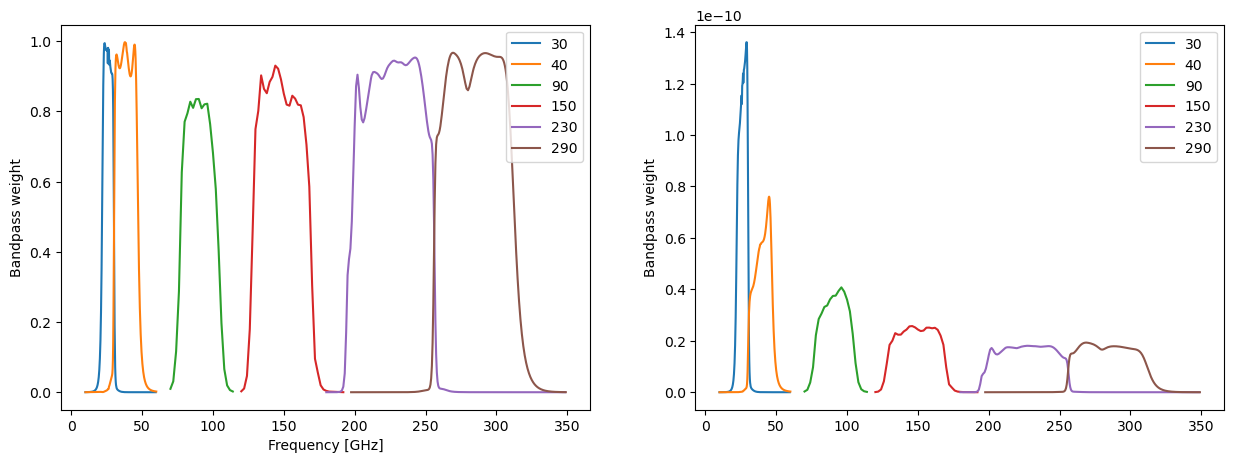

In [12]:
instrument_MSS2 = {'frequency': np.array(meta.frequencies)}
instrument_MSS2 = standardize_instrument(instrument)

use_bandpass = True

if use_bandpass:
    # freqs_with_bandpass = []
    freqs_with_bandpass_conv = []
    plt.close()
    fig, ax = plt.subplots(1,2, figsize=(15,5))

    raw_freq_and_weights = []

    for map_name in meta.maps_list:
        freq_tag = meta.map_sets[map_name]['freq_tag']
        bandpass = Table.read(f'/pscratch/sd/j/jost/SO_MEGATOP/MSS2/Coadd_fsky0.19/bandpasses/bandpass_f{freq_tag:03}.tbl', format="ascii.ipac")
        freq = np.array( bandpass['bandpass_frequency'].tolist())
        weights_raw = np.array(bandpass['bandpass_weight'].tolist())

        print(map_name, 'sample size:', len(bandpass['bandpass_weight'].tolist()))
        raw_freq_and_weights.append((freq, weights_raw))
        
        # Normalizing the bandpass weights
        weights = weights_raw / _jysr2rj(freq)
        weights /= _rj2cmb(freq) # so now on top of the weight we have the conversion factor from K_CMB to Jy/sr
        weights /= np.trapz(weights, freq * 1e9)
        freqs_with_bandpass_conv.append( (freq, weights) )

        # freqs_with_bandpass.append( ( np.array(bandpass['bandpass_frequency'].tolist()), np.array(bandpass['bandpass_weight'].tolist()) ) )

        ax[0].plot(raw_freq_and_weights[-1][0], raw_freq_and_weights[-1][1], label=f'{freq_tag}')
        ax[0].set_xlabel('Frequency [GHz]')
        ax[0].set_ylabel('Bandpass weight')
        ax[0].legend()

        ax[1].plot(freqs_with_bandpass_conv[-1][0], freqs_with_bandpass_conv[-1][1], label=f'{freq_tag}')
        ax[1].set_label('Frequency [GHz]')
        ax[1].set_ylabel('Bandpass weight')
        ax[1].legend()

    plt.show()
    
    instrument_MSS2.frequency = freqs_with_bandpass_conv
  

In [13]:
# Initializing the sky model, we ask for maps in K_CMB
sky_MSS2 = Sky(nside=128, preset_strings=['c1',"d0", "s0"], output_unit=u.K_CMB)

In [14]:

if use_bandpass:
    freq_map_bandpass_MSS2 = []
    for freq in tqdm(raw_freq_and_weights): 
        freq_map_bandpass_MSS2.append(
            sky.get_emission(freq[0] * u.GHz, 
                             freq[1] )
                            )
    freq_map_bandpass_MSS2 = np.array(freq_map_bandpass_MSS2)

100%|██████████| 6/6 [02:45<00:00, 27.59s/it]


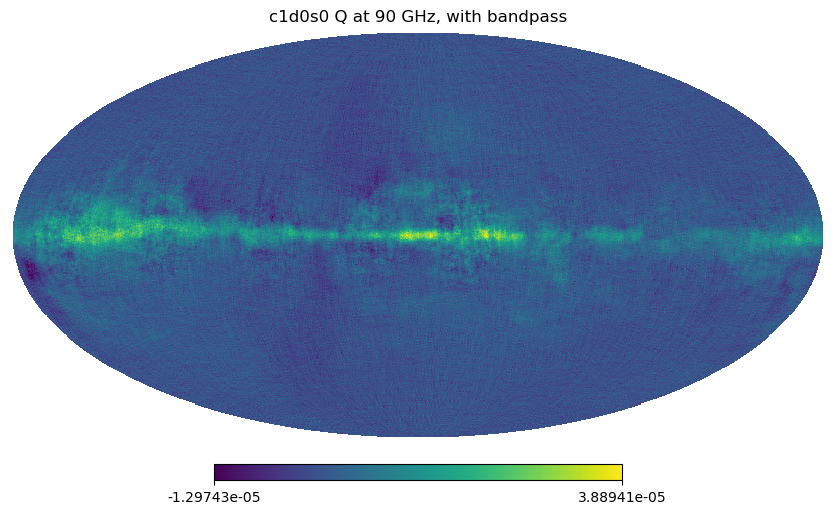

In [15]:
hp.mollview(freq_map_bandpass_MSS2[2,1], title='c1d0s0 Q at 90 GHz, with bandpass')
plt.show()


In [16]:
freq_map_bandpass_MSS2_noisy = freq_map_bandpass_MSS2 + noise_maps

In [19]:
time_comp_sep = time.time()

res_compsep_bandpass_MSS2 = fg.separation_recipes.weighted_comp_sep(components, instrument_MSS2,
            data=freq_map_bandpass_MSS2_noisy[:,1:], cov=noise_cov[:,1:], # Slice to remove the T maps, otherwise the separation will be biased
            options=options, tol=tol, method=method)
print('time comp sep =', time.time() - time_comp_sep)
print('success: ',res_compsep_bandpass.success)
print('x: ', res_compsep_bandpass.x)


time comp sep = 33.10023903846741
success:  True
x:  [ 1.54001529 -3.000335  ]


In [20]:
sigma_from_fisher_MSS2 = scipy.linalg.sqrtm(res_compsep_bandpass_MSS2.Sigma)
print('============= MSS2 BANDPASS =============')
print('CAREFULL HERE ONLY THE BANDPASS ARE THE SAME AS MSS2 THE REST IS ON THE FLY!!')
print('============= DUST INDEX ==============')
print('Relative difference in dust index using ouptut Sigma = ', 
      np.abs(sky_MSS2.components[1].mbb_index - res_compsep_bandpass_MSS2.x[0])/ sigma_from_fisher_MSS2[0,0] )

print('========== SYNCHROTRON INDEX ===========')
print('Relative difference in synchrotron index using ouptut Sigma = ', 
      np.abs(sky_MSS2.components[2].pl_index - res_compsep_bandpass_MSS2.x[1])/ sigma_from_fisher_MSS2[1,1] )
print('\n\n')


============= MSS2 BANDPASS =============
CAREFULL HERE ONLY THE BANDPASS ARE THE SAME AS MSS2 THE REST IS ON THE FLY!!
============= DUST INDEX ==============
Relative difference in dust index using ouptut Sigma =  0.12736887018039905
========== SYNCHROTRON INDEX ===========
Relative difference in synchrotron index using ouptut Sigma =  0.771519706168479



